# Compute a beam impedance

In this tutorial we put a beam on the axis of a collimator, a round pipe that narrows
from a radius of 100 mm to 50 mm and widens again, and compute its longitudinal
impedance from 0.1 to 1.1 GHz. Below the cut-off of the pipe the collimator acts on the
beam as a small inductance; we compare it with Yokoya's estimate for gentle tapers.

**Prerequisites:** [Your first simulation](../basics/first_simulation.ipynb). The
tapers are models of [Build cavities from parameters](../models/parametric_geometries.ipynb).

## 1. Build the collimator

### 1.1 Create the project

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="collimator", base_dir="./simulations", overwrite=True)

✅ Creating new project 'collimator' at simulations\collimator


### 1.2 Add the two tapers

The collimator is two tapers: one from a radius of 100 mm down to 50 mm, and one back
up. Each is 1500 mm long, with an 800 mm cone between straight pipes. The dimensions are
in millimetres, as in cavsim2d.

In [2]:
proj.create_primitive("taper", name="down", R_left=100, R_right=50, L=1500,
                      straight_left=550, straight_right=150)
proj.create_primitive("taper", name="up", R_left=50, R_right=100, L=1500,
                      straight_left=150, straight_right=550)
print(proj.geometry.describe_layout())

Main axis: Z (default). Parts follow the list order along +Z:
  1. down: z = [-0.75, 0.75] m
  2. up: z = [0.75, 2.25] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)


The two parts follow each other along +z and are glued into one mesh: a collimator
3 m long (z from -0.75 to 2.25 m), with a 300 mm flat of radius 50 mm in the middle.

### 1.3 Add the beam

A beam is a line current of 1 A that travels along the main axis (z) at the speed of
light. Without a position it runs on the axis, `x = y = 0`.

In [3]:
proj.add_beam("beam")
proj.beams

{'beam': BeamLine(name='beam', point=(0.0, 0.0, 0.0), beta=1.0, current=True)}

### 1.4 Mesh the collimator

In [4]:
proj.generate_mesh(maxh=0.035)
print(f"curve order: {proj.geometry.curve_order}")

Main axis: Z (default). Parts follow the list order along +Z:
  1. down: z = [-0.75, 0.75] m
  2. up: z = [0.75, 2.25] m
Mesh strategy: glued (one conformal mesh of all parts; all parts are geometry, each used once)

Assembly domain-material mapping:
  down: ['down/vacuum']
  up: ['up/vacuum']
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1


curve order: 4


With a beam defined, `generate_mesh()` curves the mesh to order 4: the beam's own field
is almost normal to the walls, and the beam impedance depends on how closely the mesh
follows them. Meshing prints the layout again and names the face between the two
parts `port2`, an internal port.

## 2. Solve with the beam

### 2.1 Run the sweep

Three port modes per port (TE11 in two polarisations and TM01), element order 3, and
the two parts solved as one piece (`per_domain=False`). The beam needs no extra
factorisation: the one per frequency that serves the port modes serves the beam too.

In [5]:
import time

t0 = time.time()
res = proj.fds.solve(fmin=0.1, fmax=1.1, nsamples=11, nportmodes=3, order=3,
                     per_domain=False)
print(f"solved in {time.time() - t0:.0f} s")


Structure Topology
  Type: Compound structure
  Domains (2): ['down', 'up']
  Ports (3): ['port1', 'port2', 'port3']
  Mesh elements: 5549
  External Ports (2): ['port1', 'port3']
  Internal Ports (1): ['port2']

  Domain-Port Mapping:
    down: ['port1 (input)', 'port2 (internal)']
    up: ['port2 (internal)', 'port3 (output)']



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=18.4118, sigma=+1
	port1 mode 1: TE_11 (sin), kc=18.4118, sigma=+1
	port1 mode 2: TM_01, kc=24.0483, sigma=+1
	port2 mode 0: TE_11 (cos), kc=36.8237, sigma=+1
	port2 mode 1: TE_11 (sin), kc=36.8237, sigma=+1


	port2 mode 2: TM_01, kc=48.0965, sigma=+1
	port3 mode 0: TE_11 (cos), kc=18.4118, sigma=+1
	port3 mode 1: TE_11 (sin), kc=18.4118, sigma=+1
	port3 mode 2: TM_01, kc=24.0483, sigma=+1
Port eigenmodes complete: 9 total modes



FDS Solve: 0.1000 - 1.1000 GHz, 11 samples


Global Coupled Solve


  Auto solver: 120114 unknowns, a factorisation needs about 0.7 GB of 32.8 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 19.42s


solved in 21 s


### 2.2 Read the generalised scattering matrix

Next to the S-parameters, the solve returns the generalised scattering matrix
$\tilde{S} = [[S, k], [h, z_b]]$: the port modes `1(1)` ... `2(3)`, then the beam
`b(1)`.

In [6]:
fom = proj.fds.fom
rows, cols = fom.tilde_labels
print("rows:   ", rows)
print("columns:", cols)
print(fom.s_tilde.shape)

rows:    ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)', 'b(1)']
columns: ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)', 'b(1)']
(11, 7, 7)


Eleven frequencies, seven rows and seven columns. The last column is what the beam
sends into each port mode ($k$) and, in the last row, the beam voltage per ampere with
every port mode matched ($z_b$).

### 2.3 Plot the beam impedance

The longitudinal impedance is $Z_\parallel = -z_b$, in ohm.

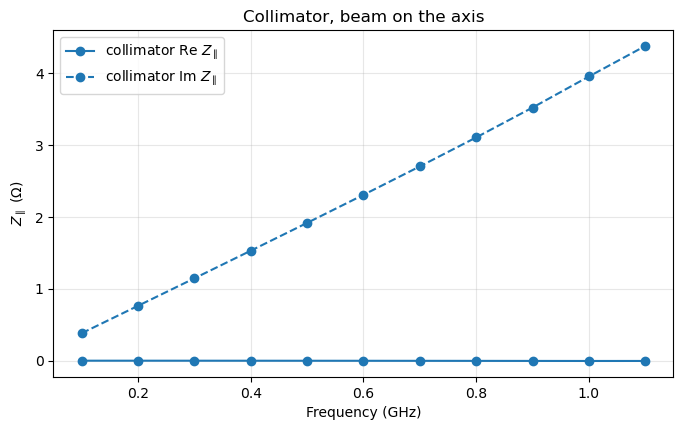

In [7]:
import matplotlib.pyplot as plt

fig, ax = fom.plot_beam_impedance(label="collimator", marker="o")
ax.set_title("Collimator, beam on the axis")
plt.show()

The imaginary part grows linearly with frequency, and the real part stays at zero: a
beam on the axis excites only the TM0n modes of the pipe, and below the cut-off of TM01
(1.15 GHz in the 100 mm pipe) none of them carries power away. The collimator stores
energy and dissipates none: an inductance.

## 3. Check against Yokoya's estimate

### 3.1 Compute the estimate

For a gentle taper, Yokoya's estimate is
$Z_\parallel = j\,\frac{k Z_0}{4\pi}\int (dr/dz)^2\,dz$. Each cone changes the radius
by 50 mm over 800 mm.

In [8]:
import numpy as np

from cavsim3d.core.constants import Z0, c0

f = fom.frequencies
slope_integral = 2 * 0.05 ** 2 / 0.8            # two cones, int (dr/dz)^2 dz in m
z_yokoya = 1j * (2 * np.pi * f / c0) * Z0 / (4 * np.pi) * slope_integral

### 3.2 Compare

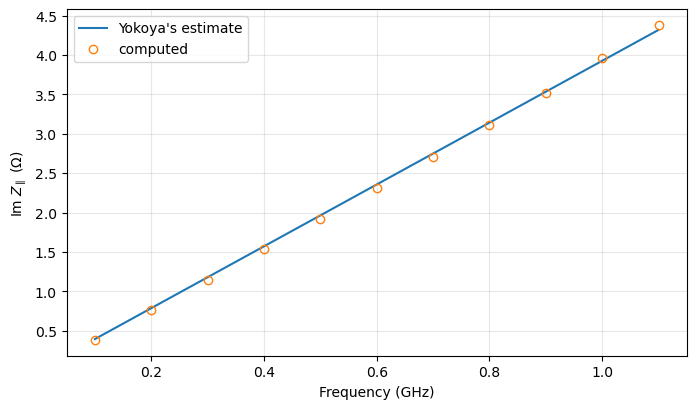

Yokoya / computed: 0.986 to 1.030
largest |Re Z_par|: 4.8e-03 Ohm


In [9]:
zpar = fom.beam_impedance()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f / 1e9, z_yokoya.imag, label="Yokoya's estimate")
ax.plot(f / 1e9, zpar.imag, lw=0, marker="o", mfc="none", label="computed")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"Im $Z_\parallel$ ($\Omega$)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

ratio = z_yokoya.imag / zpar.imag
print(f"Yokoya / computed: {ratio.min():.3f} to {ratio.max():.3f}")
print(f"largest |Re Z_par|: {np.abs(zpar.real).max():.1e} Ohm")

The estimate and the computed impedance agree within 3 % across the band (their ratio
runs from 0.986 to 1.030), and the real part stays below 0.005 Ω. Yokoya's formula
holds for gentle tapers; these cones rise by 3.6°.

## 4. See what the beam sends into the pipes

The beam's columns of $\tilde{S}$ hold the waves it sends into each port mode. Keys are
excitation first: `'b(1)1(3)'` is the beam into port 1, mode 3.

In [10]:
for m in (1, 2, 3):
    k = fom.s_tilde_dict[f"b(1)1({m})"]
    print(f"beam -> port 1, mode {m}: |k| up to {np.abs(k).max():.1e}")

beam -> port 1, mode 1: |k| up to 9.1e-06
beam -> port 1, mode 2: |k| up to 1.3e-05
beam -> port 1, mode 3: |k| up to 5.6e-03


The beam on the axis sends nothing into the two TE11 modes (`1(1)`, `1(2)`: the
1e-5 is discretisation error) and a little into TM01 (`1(3)`). Below its cut-off TM01
is evanescent, so only a small part of it reaches port 1, 550 mm from the cone.

## What we did

We built a collimator from two tapers, added a beam on its axis, solved it once for
the port modes and the beam together, and read the beam impedance from the generalised
scattering matrix. Below the cut-off it is inductive and close to Yokoya's estimate.

**Next:** [Add a beam to a solved cavity](beam_on_solved_cavity.ipynb).

**Background:** [Beam excitation](../../theory/beam.md) derives the generalised
matrices and the scattered-field formulation behind them.